In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [55]:
n = 5
poly_irred = 0x25  # x^5 + x^2 + 1
field_size = 1 << n

In [56]:
def to_latex_poly(val):
    """Convierte entero a formato LaTeX matemático."""
    if val == 0: return "$0$"
    if val == 1: return "$1$"
    parts = []
    for i in range(n - 1, -1, -1):
        if (val >> i) & 1:
            if i == 0: parts.append("1")
            elif i == 1: parts.append("x")
            else: parts.append(f"x^{{{i}}}")
    return "$" + " + ".join(parts) + "$"

In [57]:
def gf_mult(a, b, poly, n):
    """Multiplicación en GF(2^n)."""
    p = 0
    for _ in range(n):
        if b & 1: p ^= a
        high_bit = a & (1 << (n - 1))
        a <<= 1
        if high_bit: a ^= poly
        b >>= 1
    return p & ((1 << n) - 1)

In [58]:
def gf_inv(val, poly, n):
    """Encuentra el inverso multiplicativo (fuerza bruta para n pequeño)."""
    if val == 0: return 0
    for i in range(1 << n):
        if gf_mult(val, i, poly, n) == 1:
            return i
    return 0

In [62]:
print(f"Generando datos para GF(2^{n})...")

labels = [to_latex_poly(i) for i in range(1, field_size)]
mult_data = []
inv_grid_data = []

for i in range(1, field_size):
    row_mult = []
    row_inv = []
    for j in range(1, field_size):
        # Multiplicación
        prod = gf_mult(i, j, poly_irred, n)
        row_mult.append(to_latex_poly(prod))
        
        # Inverso del producto
        inv_val = gf_inv(prod, poly_irred, n)
        row_inv.append(to_latex_poly(inv_val))
            
    mult_data.append(row_mult)
    inv_grid_data.append(row_inv)

Generando datos para GF(2^5)...


In [63]:
def save_compact_grid(data, col_labels, row_labels, filename, title):
    df = pd.DataFrame(data, columns=col_labels)
    
    # Ajustes de tamaño
    if n >= 5:
        cell_width = 2.5
        cell_height = 0.8
        font_size = 12
    elif n >= 3:
        cell_width = 1.5
        cell_height = 0.8
        font_size = 10
    else:
        cell_width = 1
        cell_height = 0.6
        font_size = 8
        
    fig_width = len(col_labels) * cell_width
    fig_height = (len(data) * cell_height) + 0.5 
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    
    plt.title(title, fontsize=font_size + 4, pad=2, fontweight='bold')
    
    table = ax.table(cellText=df.values, 
                     colLabels=col_labels, 
                     rowLabels=row_labels,
                     loc='center',
                     cellLoc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 2.0)

    print(f"Generando {filename}...")
    plt.savefig(filename, bbox_inches='tight', dpi=120)
    plt.close()

Generando ./GF5/GF5_mult_table.png...


FileNotFoundError: [Errno 2] No such file or directory: './GF5/GF5_mult_table.png'

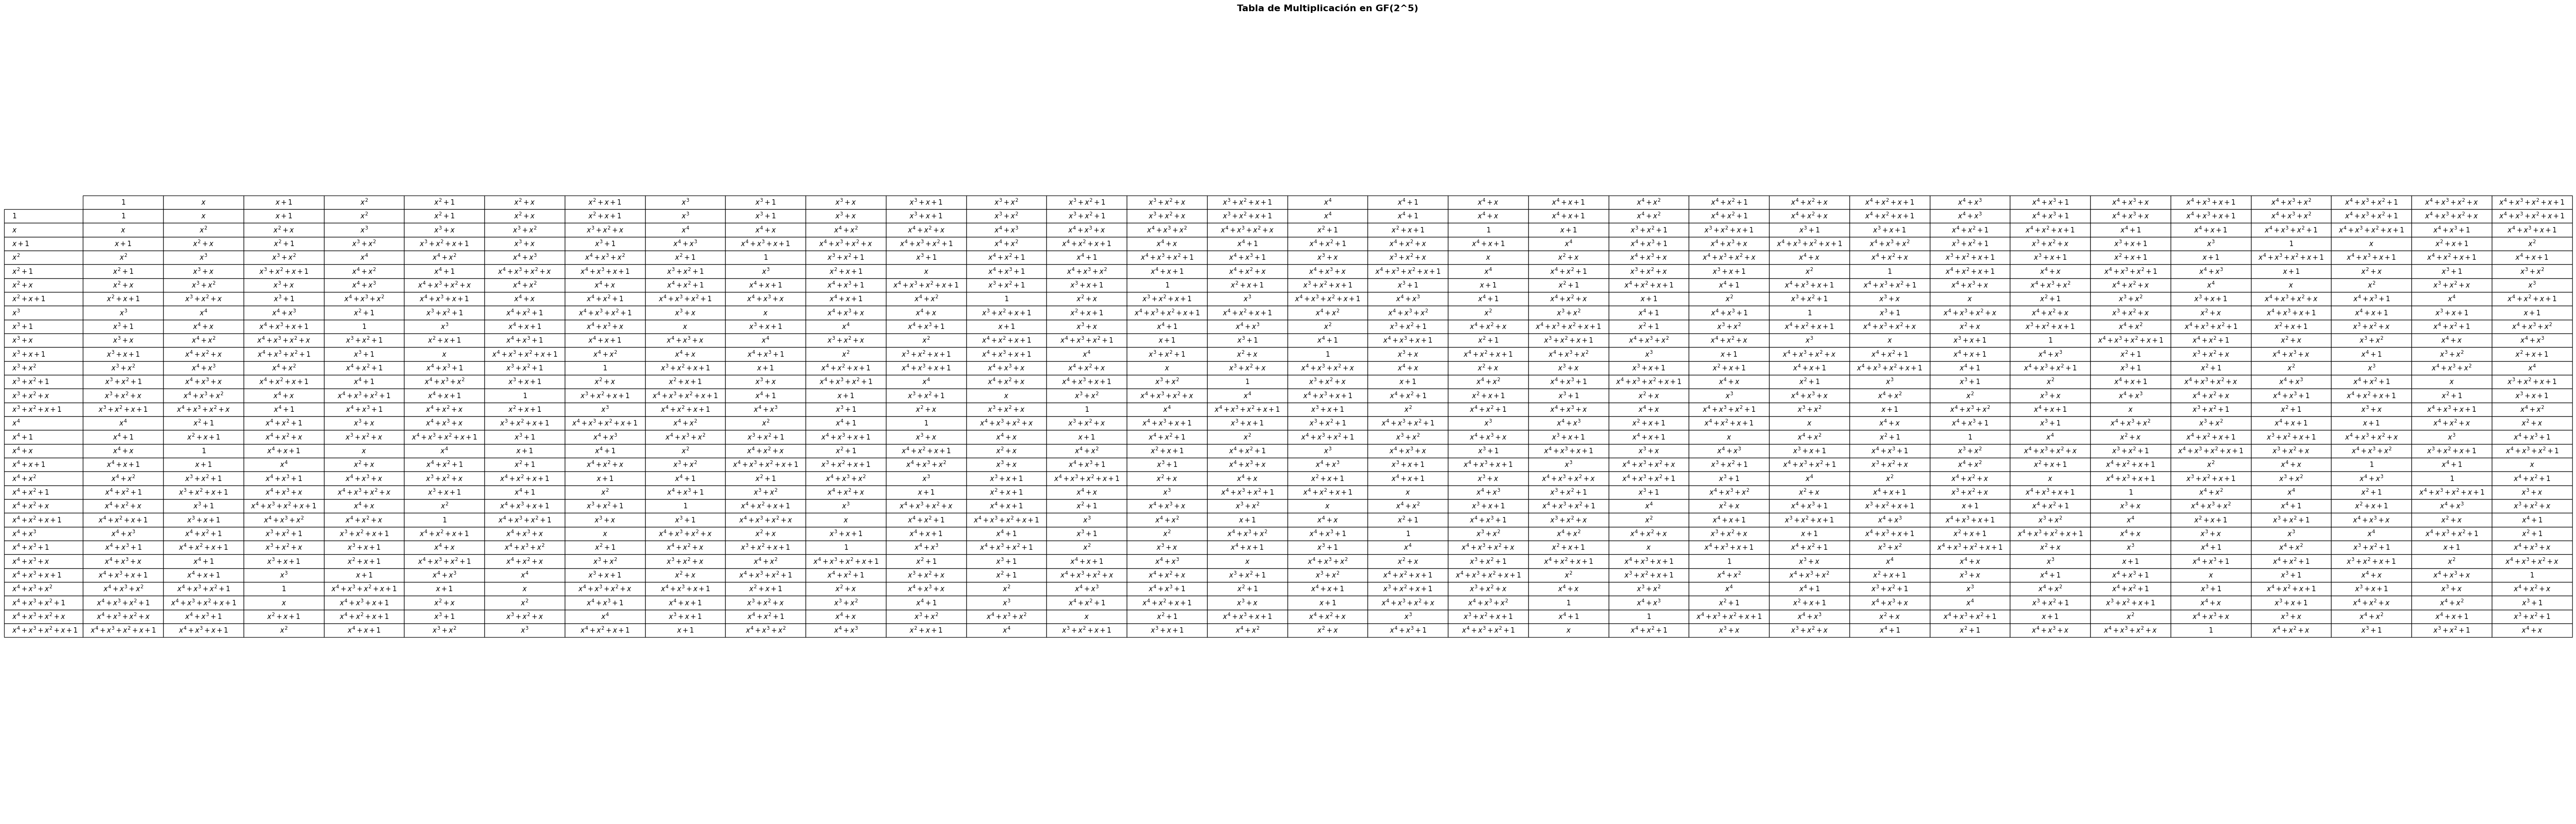

In [ ]:
path = Path(f"./GF{n}")
path.mkdir(parents=True, exist_ok=True)
save_compact_grid(mult_data, labels, labels, str(path / f"GF{n}_mult_table.png"), f"Tabla de Multiplicación en GF(2^{n})")
save_compact_grid(inv_grid_data, labels, labels, str(path / f"GF{n}_inv_grid.png"), f"Cuadrícula de Inversos en GF(2^{n})")
print("Listo.")